# Investigate Permulations

Script to investigate example permulated trees, especially any which were commonly re-used.

In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd


In [9]:
def load_permulation_tip_values_from_csv(csv_path):
    """Load permulated tip values from a CSV file."""

    tip_df = pd.read_csv(csv_path)
    if tip_df.empty:
        raise ValueError(f"Permulation tip-values CSV is empty: {csv_path}")

    species_cols = [c for c in tip_df.columns if c != "perm_id"]
    if not species_cols:
        raise ValueError(
            f"Permulation tip-values CSV has no species columns: {csv_path}"
        )

    tip_numeric = tip_df[species_cols].apply(pd.to_numeric, errors="raise")
    if tip_numeric.isnull().any().any():
        raise ValueError(f"Permulation tip-values CSV contains NaN values: {csv_path}")

    return [
        {species: float(value) for species, value in row.items()}
        for row in tip_numeric.to_dict(orient="records")
    ]

In [10]:
from collections import Counter
from pathlib import Path
import json

from Bio import Phylo
import matplotlib.pyplot as plt


def plot_most_reused_permulation_tree(
    permulation_tip_values,
    newick_path,
    fig_width=12,
    per_tip_height=0.22,
    title_prefix="Most re-used permulation",
):
    """Plot a Newick tree with tip labels annotated by the most frequent permulation tip-value map."""
    serialized = [json.dumps(d, sort_keys=True, default=str) for d in permulation_tip_values]
    counts = Counter(serialized)

    most_common_serialized, most_common_count = counts.most_common(1)[0]
    most_common_dict = json.loads(most_common_serialized)

    tree = Phylo.read(str(newick_path), "newick")
    tree_tip_names = {t.name for t in tree.get_terminals()}
    value_tip_names = set(most_common_dict.keys())

    missing_in_values = sorted(tree_tip_names - value_tip_names)
    missing_in_tree = sorted(value_tip_names - tree_tip_names)

    print(f"Total permulations: {len(permulation_tip_values)}")
    print(f"Unique tip-value maps: {len(counts)}")
    print(f"Most duplicated map count: {most_common_count}")
    print(f"Tree tips: {len(tree_tip_names)}")
    print(f"Dictionary keys: {len(value_tip_names)}")
    print(f"Tips missing values: {len(missing_in_values)}")
    print(f"Dictionary keys not in tree: {len(missing_in_tree)}")

    if missing_in_values:
        print("Example missing values:", missing_in_values[:10])
    if missing_in_tree:
        print("Example keys not in tree:", missing_in_tree[:10])

    def format_tip_label(clade):
        if not clade.is_terminal():
            return None
        value = most_common_dict.get(clade.name, "NA")
        if isinstance(value, (int, float)) and float(value).is_integer():
            value = int(value)
        return f"{clade.name}: {value}"

    fig_height = max(8, len(tree_tip_names) * per_tip_height)
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_subplot(111)
    Phylo.draw(tree, axes=ax, do_show=False, label_func=format_tip_label)
    ax.set_title(f"{title_prefix} (n={most_common_count})")
    plt.tight_layout()
    plt.show()

    return most_common_dict, most_common_count

In [12]:
def plot_random_permulation_tree(
    permulation_tip_values,
    newick_path,
    fig_width=12,
    per_tip_height=0.22,
    title_prefix="Random permulation",
):
    """Plot a Newick tree with tip labels annotated by a random permulation tip-value map."""
    if not permulation_tip_values:
        raise ValueError("No permulation tip values provided.")

    random_dict = np.random.choice(permulation_tip_values)

    tree = Phylo.read(str(newick_path), "newick")
    tree_tip_names = {t.name for t in tree.get_terminals()}
    value_tip_names = set(random_dict.keys())

    missing_in_values = sorted(tree_tip_names - value_tip_names)
    missing_in_tree = sorted(value_tip_names - tree_tip_names)

    print(f"Total permulations: {len(permulation_tip_values)}")
    print(f"Tree tips: {len(tree_tip_names)}")
    print(f"Dictionary keys: {len(value_tip_names)}")
    print(f"Tips missing values: {len(missing_in_values)}")
    print(f"Dictionary keys not in tree: {len(missing_in_tree)}")

    if missing_in_values:
        print("Example missing values:", missing_in_values[:10])
    if missing_in_tree:
        print("Example keys not in tree:", missing_in_tree[:10])

    def format_tip_label(clade):
        if not clade.is_terminal():
            return None
        value = random_dict.get(clade.name, "NA")
        if isinstance(value, (int, float)) and float(value).is_integer():
            value = int(value)
        return f"{clade.name}: {value}"

    fig_height = max(8, len(tree_tip_names) * per_tip_height)
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_subplot(111)
    Phylo.draw(tree, axes=ax, do_show=False, label_func=format_tip_label)
    ax.set_title(f"{title_prefix}")
    plt.tight_layout()
    plt.show()

Total permulations: 10000
Unique tip-value maps: 9942
Most duplicated map count: 17
Tree tips: 103
Dictionary keys: 98
Tips missing values: 5
Dictionary keys not in tree: 0
Example missing values: ['Antrodiaetus_roretzi', 'Drosophila_melanogaster', 'Falcileptoneta_japonica', 'Masirana_silvicola', 'Orchestina_okitsui']


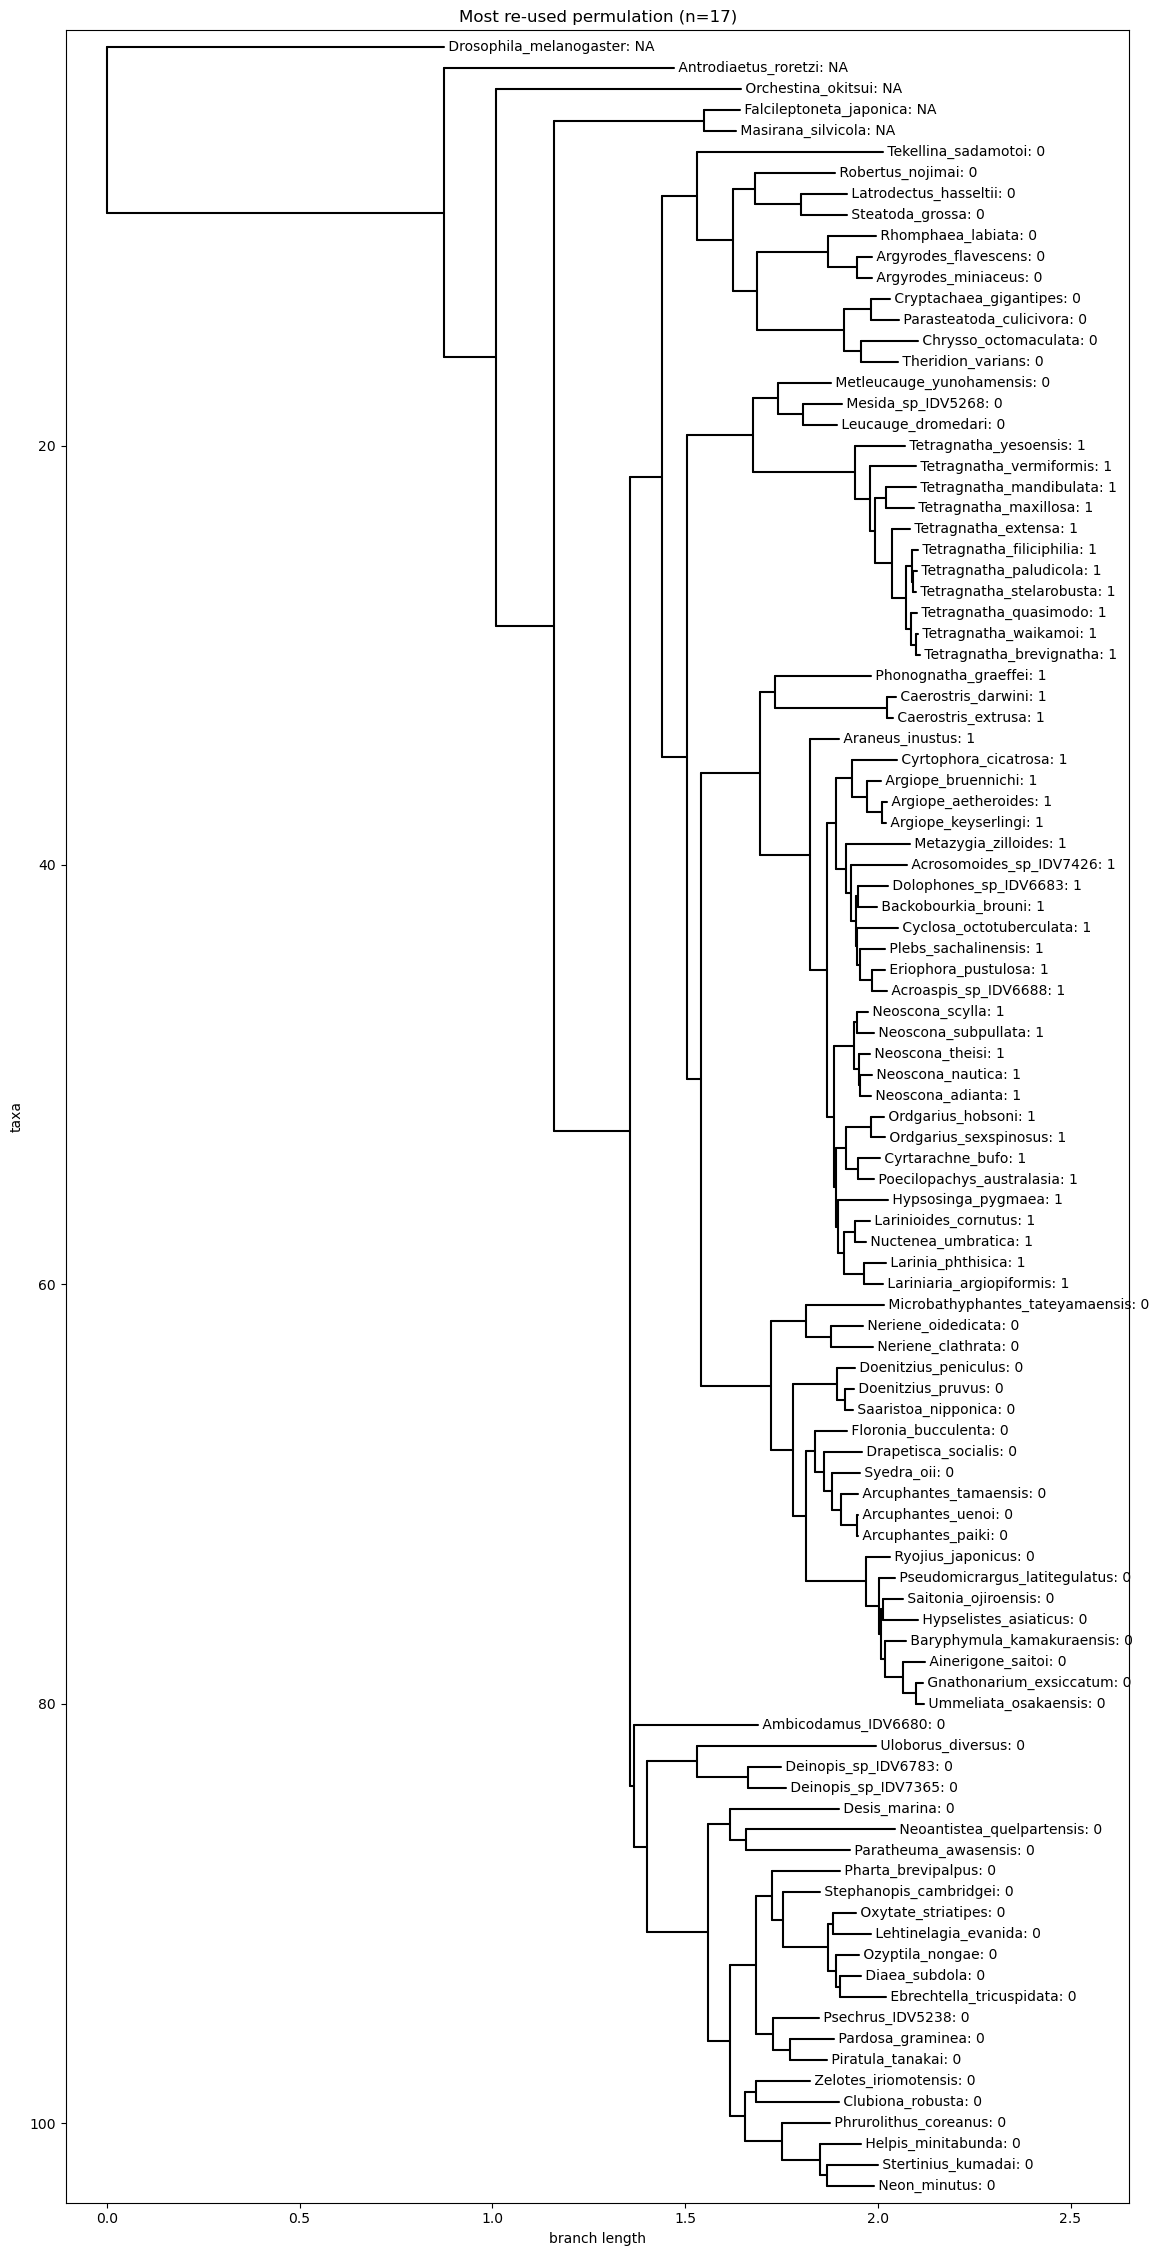

In [14]:
newick_path = Path(repo_root) / "data" / "SpeciesTree_full_brlen.nwk"

permulation_csv_path = Path(repo_root) / "data" / "perms_tip_values.csv"

permulation_tip_values = load_permulation_tip_values_from_csv(permulation_csv_path)

most_common_dict, most_common_count = plot_most_reused_permulation_tree(
    permulation_tip_values,
    newick_path,
)

Total permulations: 10000
Tree tips: 103
Dictionary keys: 98
Tips missing values: 5
Dictionary keys not in tree: 0
Example missing values: ['Antrodiaetus_roretzi', 'Drosophila_melanogaster', 'Falcileptoneta_japonica', 'Masirana_silvicola', 'Orchestina_okitsui']


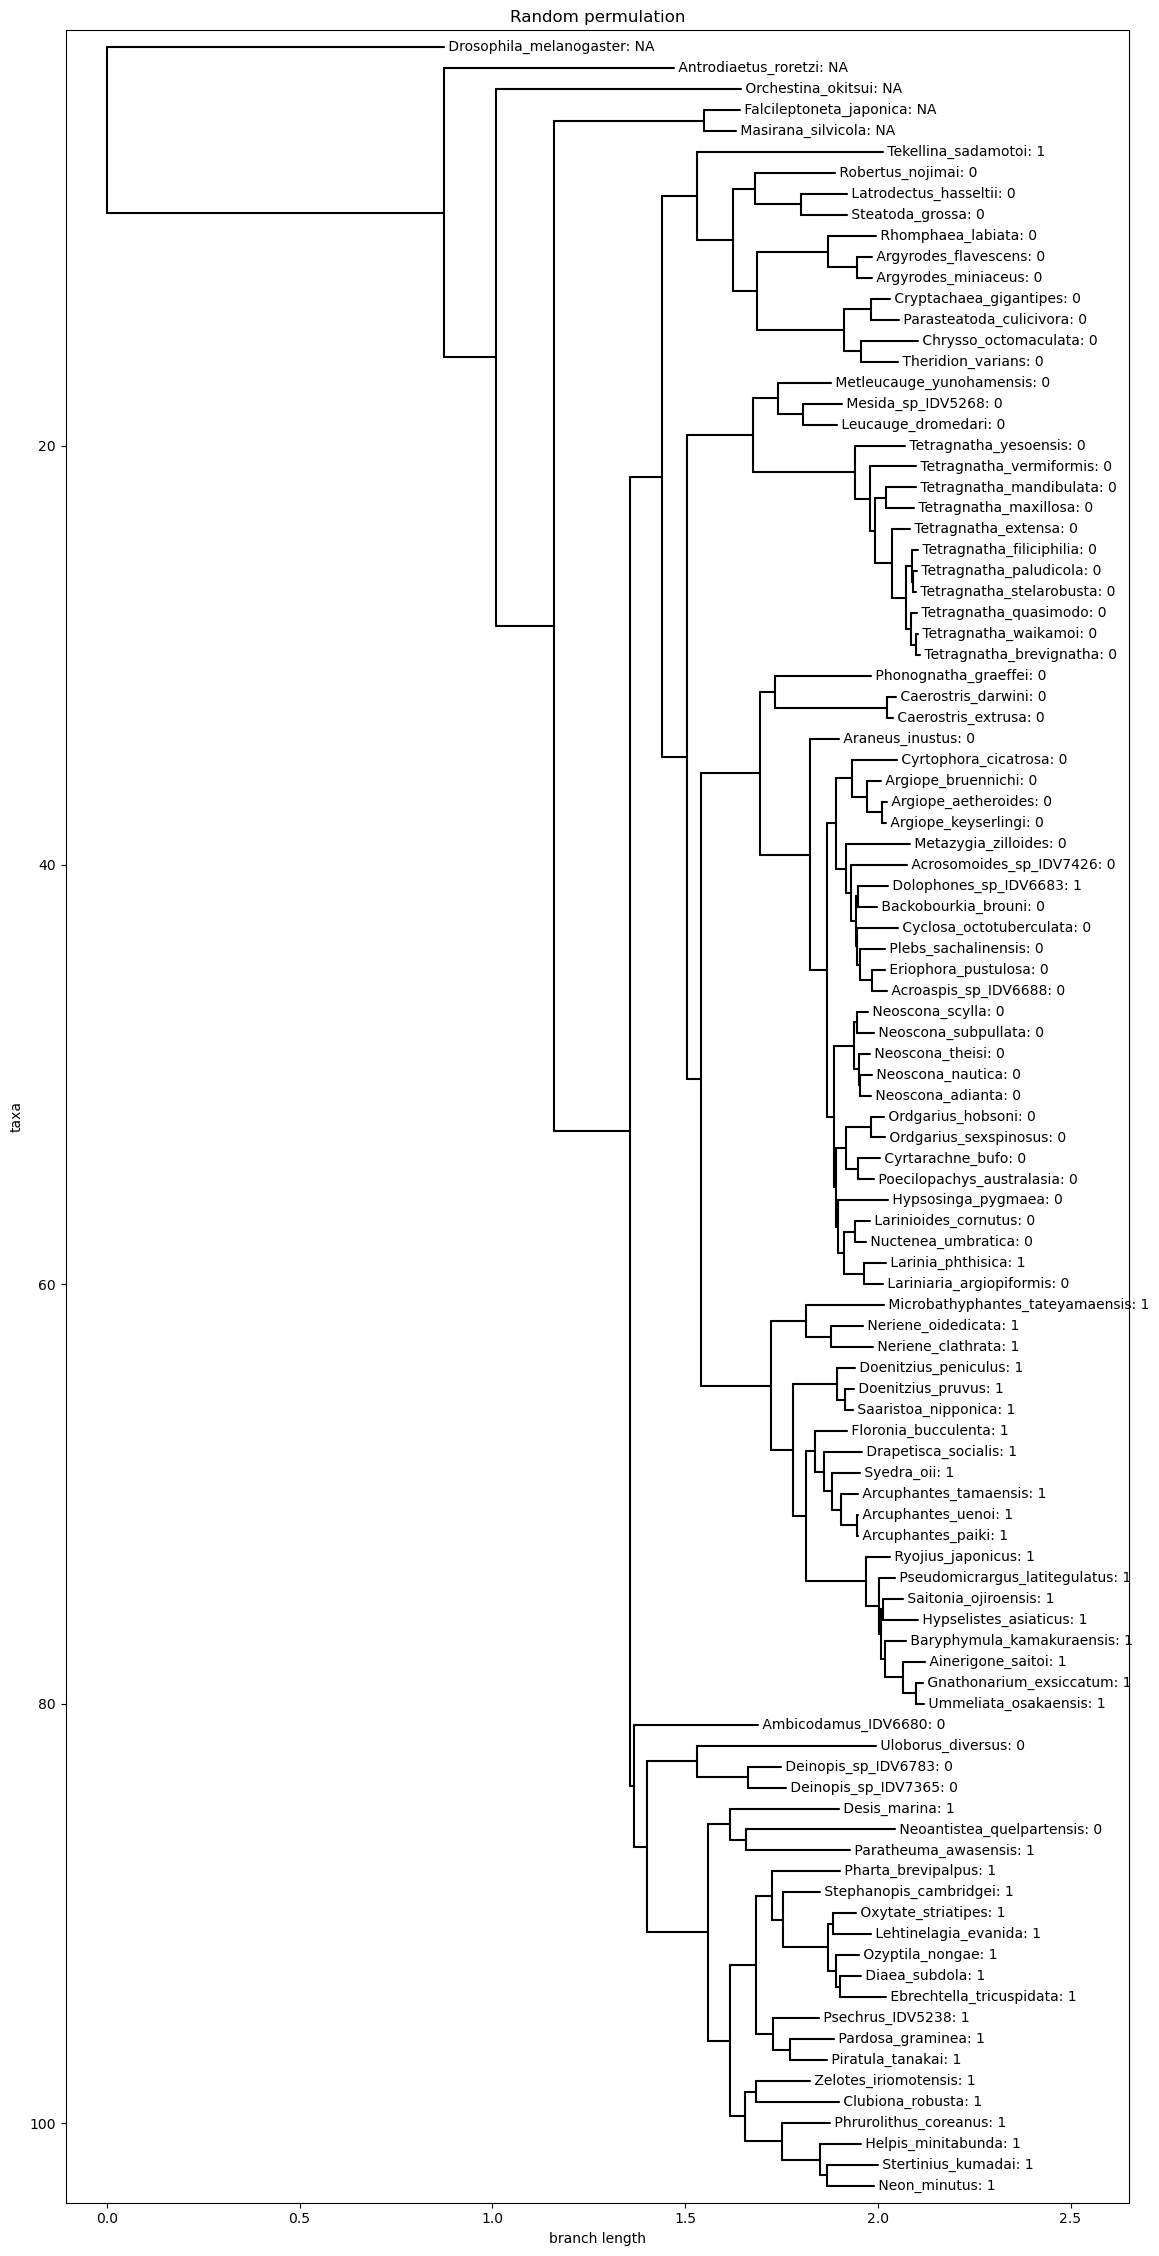

In [15]:
plot_random_permulation_tree(
    permulation_tip_values,
    newick_path,
)